In [1]:
import torch
import torch.nn as nn
import random
import matplotlib.pyplot as plt
from IPython.display import display
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
#import wandb
from scipy.stats import gaussian_kde
import numpy as np
seed = 1

In [23]:
def generate_gaussian_point_2d(n_points, mean=0.0, std=1.0, device='cpu', seed=None):
    """
    Generate 2D Gaussian white noise points using PyTorch.
    
    Args:
        n_points (int): Number of points to generate
        mean (float): Mean of the Gaussian distribution (default: 0.0)
        std (float): Standard deviation of the Gaussian distribution (default: 1.0)
        device (str): Device to create tensor on ('cpu' or 'cuda')
        seed (int, optional): Random seed for reproducibility (default: None)
    
    Returns:
        torch.Tensor: Tensor of shape (n_points, 2) containing 2D noise points
    """
    if seed is not None:
        torch.manual_seed(seed)
    
    points = torch.randn(n_points, 2, device=device) * std + mean
    return points

def plot_points_2d(points, title=None, figsize=(8, 8), color='blue', ax=None, show=True, label=None):
    """
    Plot 2D points on a plane.
    
    Args:
        points (torch.Tensor): Tensor of shape (n_points, 2)
        title (str): Title for the plot
        figsize (tuple): Figure size (width, height)
        color (str): Color for the points (default: 'blue')
        ax (matplotlib.axes.Axes): Existing axes to plot on (default: None, creates new figure)
        show (bool): Whether to call plt.show() (default: True)
        label (str): Label for the legend (default: None)
    
    Returns:
        matplotlib.axes.Axes: The axes object
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
        ax.set_title(title)
    
    ax.scatter(points[:, 0].cpu(), points[:, 1].cpu(), alpha=0.6, s=30, color=color, label=label)
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    if title is not None:
        ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.axis('equal')
    
    if label is not None:
        ax.legend()
    
    if show:
        plt.show()
    
    return ax

def plot_vector_field(model, xlim=(-3, 3), ylim=(-3, 3), grid_size=20, title='Vector Field', figsize=(10, 10), ax=None, show=True):
    """
    Plot the vector field defined by the neural network (ODE-Net).
    
    Args:
        model (nn.Module): Neural network model that outputs 2D vectors
        xlim (tuple): X-axis limits (default: (-3, 3))
        ylim (tuple): Y-axis limits (default: (-3, 3))
        grid_size (int): Number of grid points in each dimension (default: 20)
        title (str): Title for the plot
        figsize (tuple): Figure size (width, height)
        ax (matplotlib.axes.Axes): Existing axes to plot on (default: None, creates new figure)
        show (bool): Whether to call plt.show() (default: True)
    
    Returns:
        matplotlib.axes.Axes: The axes object
    """
    # Create a grid of points
    x = torch.linspace(xlim[0], xlim[1], grid_size)
    y = torch.linspace(ylim[0], ylim[1], grid_size)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    
    # Flatten the grid
    grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)
    
    # Get the vector field from the model
    model.eval()
    with torch.no_grad():
        vectors = model(grid_points)
    
    # Reshape back to grid
    U = vectors[:, 0].reshape(grid_size, grid_size).cpu().numpy()
    V = vectors[:, 1].reshape(grid_size, grid_size).cpu().numpy()
    X_np = X.cpu().numpy()
    Y_np = Y.cpu().numpy()
    
    # Plot the vector field
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)
    
    ax.quiver(X_np, Y_np, U, V, alpha=0.8, angles="xy", scale_units="xy", headlength=4, scale=2, width=None)  ## assuming 2 ODE steps, that means the arror is the length of each step 
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.axhline(y=0, color='k', linewidth=0.5)
    ax.axvline(x=0, color='k', linewidth=0.5)
    ax.axis('equal')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    
    if show:
        #display(plt.figure())
        plt.show()
    
    return ax

def plot_vector_field_multi(model, noise_points, target_points, xlim=(-3, 3), ylim=(-3, 3), grid_size=20, title='Vector Field', figsize=(10, 10), ax=None, show=True, num_time_steps=1, t_values=None):
    """
    Plot the vector field defined by the neural network (ODE-Net) at different time steps.
    
    Args:
        model (nn.Module): Neural network model that outputs 2D vectors
        xlim (tuple): X-axis limits (default: (-3, 3))
        ylim (tuple): Y-axis limits (default: (-3, 3))
        grid_size (int): Number of grid points in each dimension (default: 20)
        title (str): Title for the plot
        figsize (tuple): Figure size (width, height)
        ax (matplotlib.axes.Axes): Existing axes to plot on (default: None, creates new figure)
        show (bool): Whether to call plt.show() (default: True)
        num_time_steps (int): Number of time steps to plot (default: 1, plots at t=0.5)
        t_values (list): Specific t values to plot (overrides num_time_steps if provided)
    
    Returns:
        matplotlib.axes.Axes or list: The axes object(s)
    """
    # Determine time values to plot
    if t_values is None:
        if num_time_steps == 1:
            t_values = [0.5]
        else:
            t_values = torch.linspace(0, 1, num_time_steps).tolist()
    
    # Create grid of spatial points
    x = torch.linspace(xlim[0], xlim[1], grid_size)
    y = torch.linspace(ylim[0], ylim[1], grid_size)
    X, Y = torch.meshgrid(x, y, indexing='ij')
    grid_points = torch.stack([X.flatten(), Y.flatten()], dim=1)
    
    model.eval()
    
    # If single time step and ax provided, use it
    if len(t_values) == 1 and ax is not None:
        t = torch.full((grid_points.shape[0], 1), t_values[0])
        
        with torch.no_grad():
            vectors = model(grid_points, t)
        
        U = vectors[:, 0].reshape(grid_size, grid_size).cpu().numpy()
        V = vectors[:, 1].reshape(grid_size, grid_size).cpu().numpy()
        X_np = X.cpu().numpy()
        Y_np = Y.cpu().numpy()
        ax.quiver(X_np, Y_np, U, V, alpha=0.8, angles="xy", scale_units="xy", headlength=4, scale=2, width=None)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(f"{title} (t={t_values[0]:.2f})")
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linewidth=0.5)
        ax.axvline(x=0, color='k', linewidth=0.5)
        ax.axis('equal')
        plot_points_2d(noise_points, color='red', ax=ax, title=title, show=False, label="noise")
        plot_points_2d(target_points, color='blue', ax=ax, title=title, show=False, label="targets")
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        
        if show:
            plt.show()
        
        return ax
    
    # Multiple time steps - create subplots
    num_plots = len(t_values)
    #cols = min(3, num_plots)
    cols = 1
    rows = (num_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(figsize[0]*cols, figsize[1] * rows))
    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    
    for idx, t_val in enumerate(t_values):
        t = torch.full((grid_points.shape[0], 1), t_val)
        
        with torch.no_grad():
            vectors = model(grid_points, t)
        
        U = vectors[:, 0].reshape(grid_size, grid_size).cpu().numpy()
        V = vectors[:, 1].reshape(grid_size, grid_size).cpu().numpy()
        X_np = X.cpu().numpy()
        Y_np = Y.cpu().numpy()
        print(f"t={t_val:.2f}, mean magnitude: {torch.norm(vectors, dim=-1).mean():.4f}")
        ax_curr = axes[idx]
        ax_curr.quiver(X_np, Y_np, U, V, alpha=0.8, angles="xy", scale_units="xy", headlength=4, scale=2, width=None)
        ax_curr.set_xlabel('X')
        ax_curr.set_ylabel('Y')
        ax_curr.set_title(f"{title} (t={t_val:.2f})")
        plot_points_2d(noise_points, color='red', ax=ax_curr, show=False)
        plot_points_2d(target_points, color='blue', ax=ax_curr, show=False)
        ax_curr.grid(True, alpha=0.3)
        ax_curr.axhline(y=0, color='k', linewidth=0.5)
        ax_curr.axvline(x=0, color='k', linewidth=0.5)
        ax_curr.axis('equal')
        ax_curr.set_xlim(xlim)
        ax_curr.set_ylim(ylim)
    
    # Hide unused subplots
    for idx in range(num_plots, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    
    if show:
        plt.show()
    
    return axes

def train_flow_matching(model, source_data, target_data, batch_size=64, num_epochs=100, lr=1e-3, device='cpu', warmup_epochs=5, use_wandb=False, project_name="flow-matching", run_name=None):
    """
    Train the model using flow matching objective.
    
    Flow matching learns to transform source distribution to target distribution.
    At time t, we interpolate: x_t = (1-t)*x_0 + t*x_1
    The velocity is: v_t = x_1 - x_0
    
    Args:
        model (nn.Module): Neural network model (ODE-Net)
        source_data (torch.Tensor): Source distribution data (e.g., noise)
        target_data (torch.Tensor): Target distribution data
        batch_size (int): Batch size for training
        num_epochs (int): Number of training epochs
        lr (float): Learning rate
        device (str): Device to train on ('cpu' or 'cuda')
        warmup_epochs (int): Number of epochs for learning rate warmup
        use_wandb (bool): Whether to use Weights & Biases for tracking
        project_name (str): W&B project name
        run_name (str): W&B run name (optional)
    
    Returns:
        list: Training losses
    """
    model = model.to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    
    # Cosine annealing scheduler with warmup
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs - warmup_epochs, eta_min=lr * 0.1)
    
    # Initialize W&B if requested
    if use_wandb:
        wandb.init(
            project=project_name,
            entity="frankcao613-ntnu",
            name=run_name,
            config={
                "learning_rate": lr,
                "epochs": num_epochs,
                "batch_size": batch_size,
                "warmup_epochs": warmup_epochs,
                "model_architecture": str(model),
                "source_data_size": source_data.shape[0],
                "target_data_size": target_data.shape[0],
            }
        )
        wandb.watch(model, log="all", log_freq=100)
    
    # Create dataset and dataloader
    dataset = TensorDataset(source_data, target_data)
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    
    losses = []
    
    for epoch in range(num_epochs):
        # Warmup: gradually increase learning rate
        if epoch < warmup_epochs:
            warmup_lr = lr * (epoch + 1) / warmup_epochs
            for param_group in optimizer.param_groups:
                param_group['lr'] = warmup_lr
        
        epoch_loss = 0.0
        num_batches = 0
        
        for x0, x1 in dataloader:
            x0, x1 = x0.to(device), x1.to(device)
            
            # Sample random time t ~ Uniform(0, 1)
            t = torch.rand(x0.shape[0], 1, device=device)
            
            # Interpolate between source and target
            x_t = (1 - t) * x0 + t * x1
            
            # True velocity (target direction)
            v_true = x1 - x0
            
            # Predicted velocity from model
            v_pred = model(x_t, t)
            
            # Flow matching loss (MSE between predicted and true velocity)
            loss = torch.mean((v_pred - v_true) ** 2)
            
            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            epoch_loss += loss.item()
            num_batches += 1
        
        # Step scheduler after warmup
        if epoch >= warmup_epochs:
            scheduler.step()
        
        avg_loss = epoch_loss / num_batches
        losses.append(avg_loss)
        
        # Get current learning rate
        current_lr = optimizer.param_groups[0]['lr']
        
        # Log to W&B
        if use_wandb:
            wandb.log({
                "epoch": epoch + 1,
                "train_loss": avg_loss,
                "learning_rate": current_lr,
            })
        
        if (epoch + 1) % 10 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.6f}, LR: {current_lr:.6f}")
    
    # Finish W&B run
    if use_wandb:
        wandb.finish()
    
    return losses


In [3]:
class FeedForwardNetwork(nn.Module):
    """
    Simple feed-forward neural network with time embedding for ODE-Net.
    """
    def __init__(self, input_dim, num_layers, hidden_units, output_dim=1, time_embed_dim=16, seed=None):
        """
        Initialize the feed-forward network with time embedding.
        
        Args:
            input_dim (int): Dimension of the input
            num_layers (int): Number of hidden layers
            hidden_units (int): Number of units in each hidden layer
            output_dim (int): Dimension of the output (default: 1)
            time_embed_dim (int): Dimension of time embedding (default: 16)
            seed (int, optional): Random seed for weight initialization (default: None)
        """
        super(FeedForwardNetwork, self).__init__()
        
        if seed is None:
            seed = random.randint(0, 2**32 - 1)
        
        torch.manual_seed(seed)
        
        self.time_embed_dim = time_embed_dim
        
        # Time embedding projection - simple linear layer
        self.time_proj = nn.Linear(time_embed_dim, hidden_units)
        
        # Layer normalization after time addition
        self.norm = nn.LayerNorm(hidden_units)
        
        layers = []
        
        # Input layer - processes spatial input only
        layers.append(nn.Linear(input_dim, hidden_units))
        layers.append(nn.ReLU())
        
        # Hidden layers
        for _ in range(num_layers - 1):
            layers.append(nn.Linear(hidden_units, hidden_units))
            layers.append(nn.ReLU())
        
        # Output layer
        layers.append(nn.Linear(hidden_units, output_dim))
        
        self.network = nn.ModuleList(layers)
    
    def time_embedding(self, t):
        """
        Create sinusoidal time embedding.
        
        Args:
            t (torch.Tensor): Time values, shape (batch_size, 1)
        
        Returns:
            torch.Tensor: Time embeddings, shape (batch_size, time_embed_dim)
        """
        half_dim = self.time_embed_dim // 2
        embeddings = torch.log(torch.tensor(10000.0)) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=t.device) * -embeddings)
        embeddings = t * embeddings.unsqueeze(0)
        embeddings = torch.cat([torch.sin(embeddings), torch.cos(embeddings)], dim=-1)
        return embeddings
    
    def forward(self, x, t):
        """
        Forward pass through the network with time conditioning.
        
        Args:
            x (torch.Tensor): Input tensor, shape (batch_size, input_dim)
            t (torch.Tensor): Time values, shape (batch_size, 1) or (batch_size,)
        
        Returns:
            torch.Tensor: Output tensor
        """
        # Ensure t has correct shape
        if t.dim() == 1:
            t = t.unsqueeze(1)
        
        # Get time embedding and project to hidden dimension
        t_emb = self.time_embedding(t)
        t_emb = self.time_proj(t_emb)
        
        # Process spatial input through first layer
        h = self.network[0](x)  # Linear
        h = self.network[1](h)  # ReLU
        
        # Add time embedding to first hidden layer
        h = h + t_emb
        
        # Normalize the combined features
        h = self.norm(h)
        
        # Pass through remaining layers
        for layer in self.network[2:]:
            h = layer(h)
        
        return h

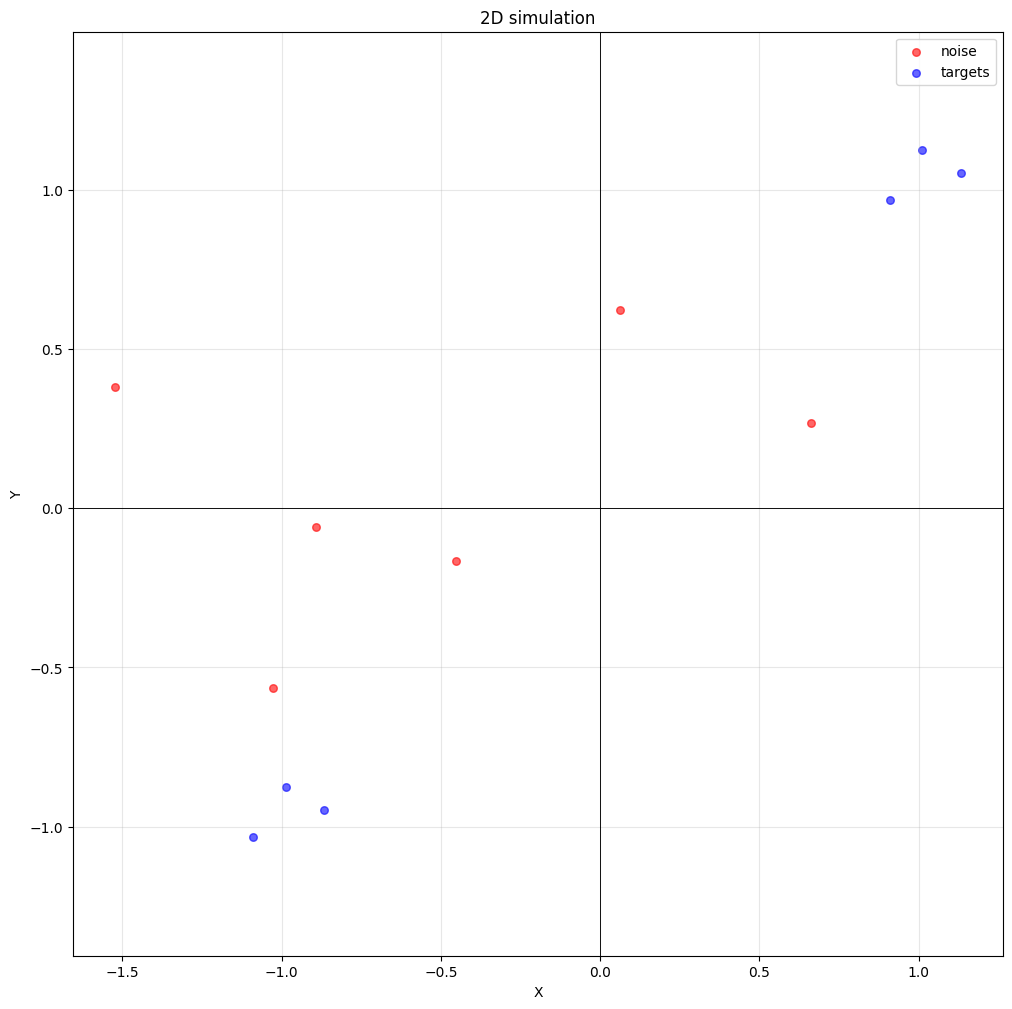

In [18]:
###generate the points
n_points = 3

points= generate_gaussian_point_2d(n_points, mean=1.0, std=0.2, seed=seed)
points= torch.concat((points, generate_gaussian_point_2d(n_points, mean=-1.0, std=0.2, seed=seed)))
noise_points= generate_gaussian_point_2d(points.shape[0], seed=seed)

ax = plot_points_2d(noise_points, color='red', figsize=(12, 12), show=False, label="noise")
ax = plot_points_2d(points, title="2D simulation", color='blue', ax=ax, show=True, label="targets")



Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


t=0.00, mean magnitude: 0.0930
t=0.33, mean magnitude: 0.0878
t=0.67, mean magnitude: 0.0837
t=1.00, mean magnitude: 0.0813


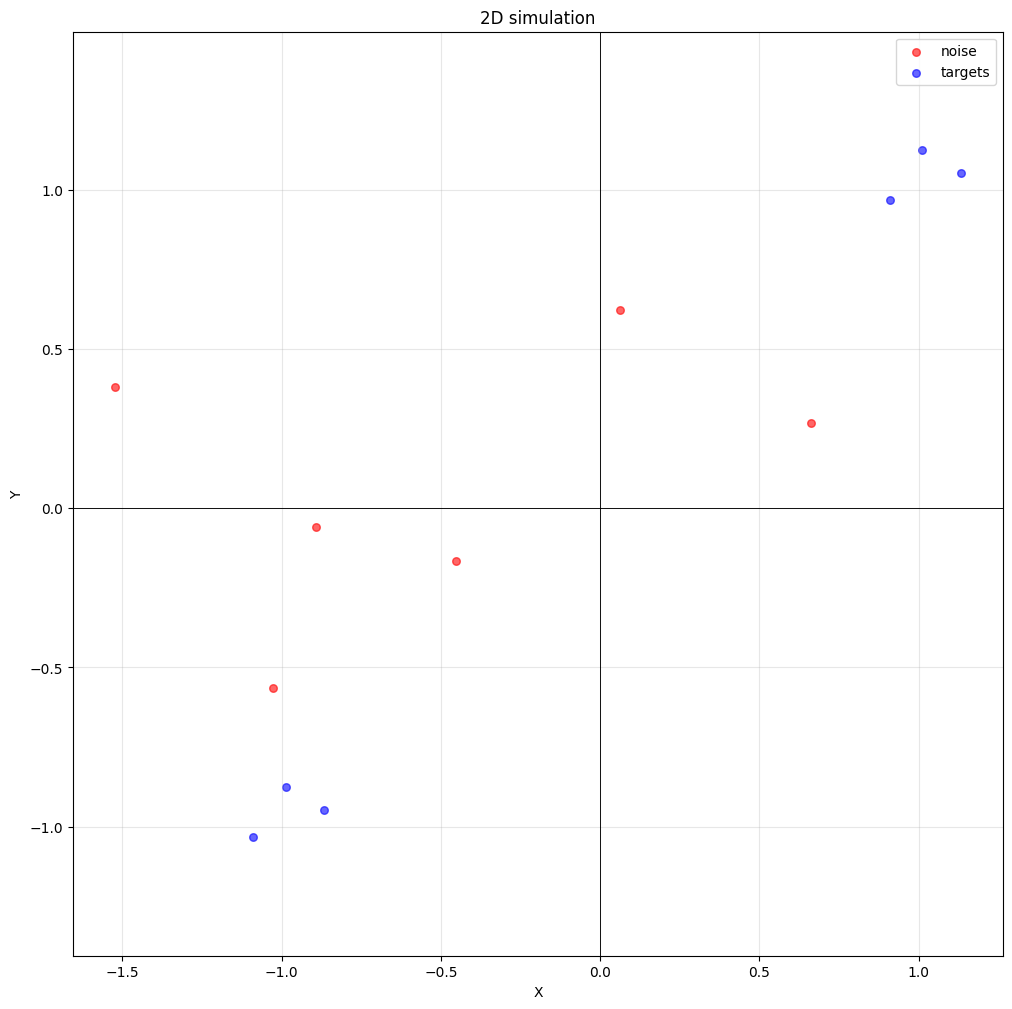

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


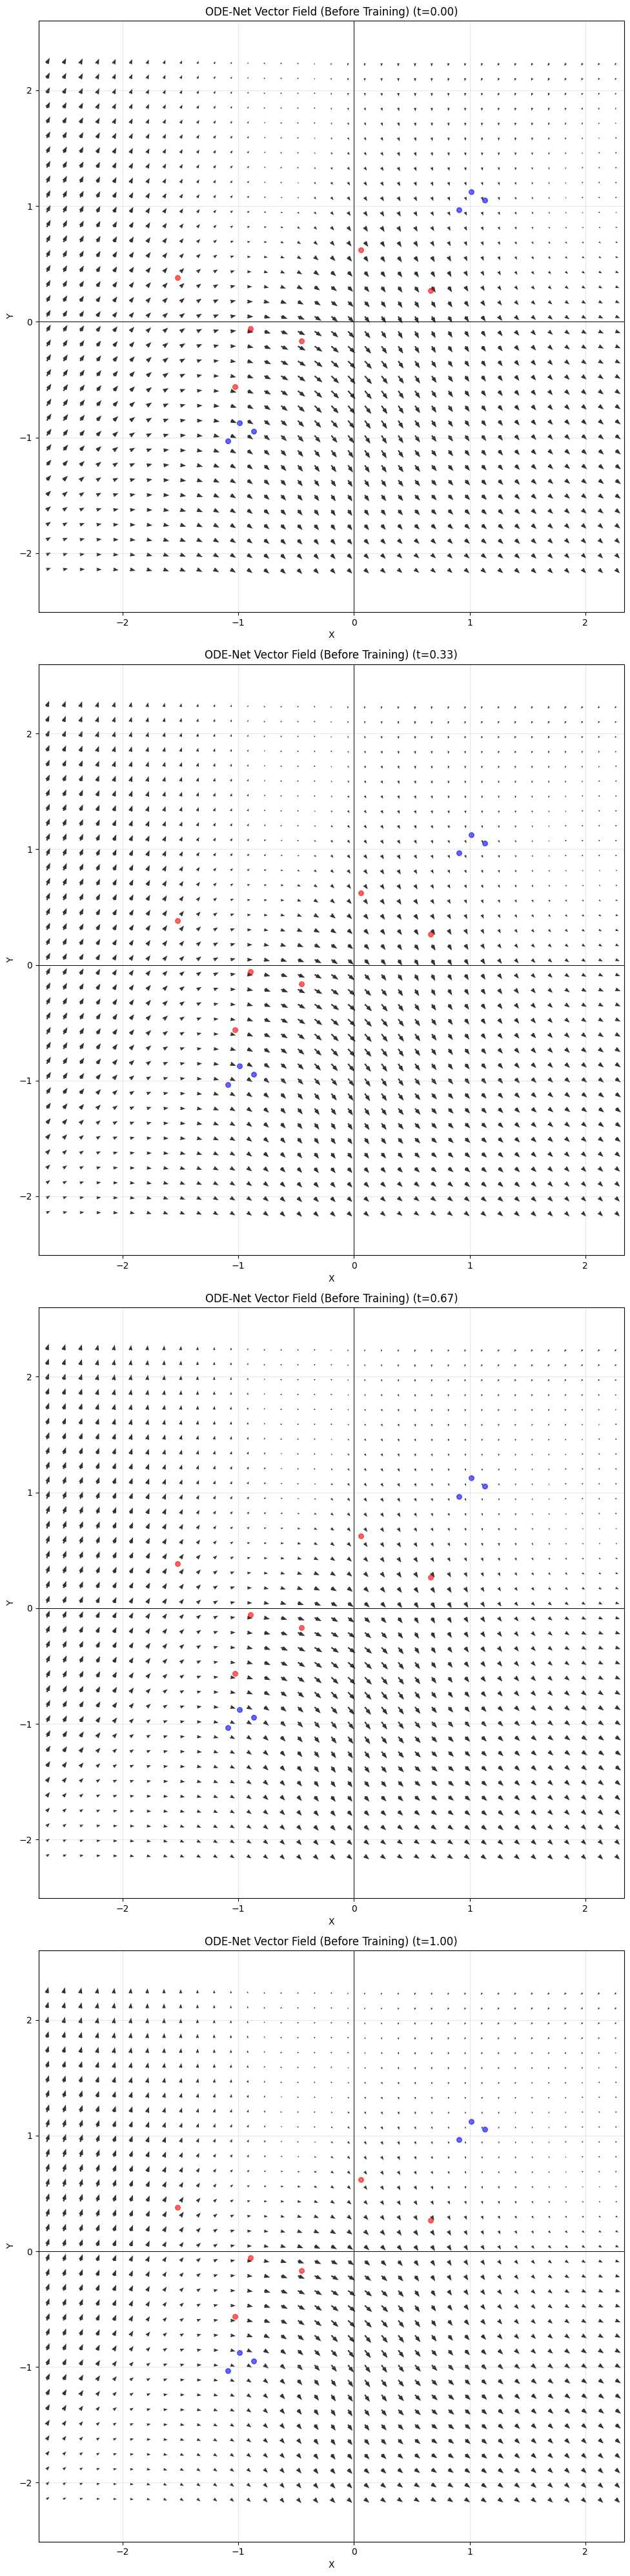

In [24]:
##randomnize a model
model = FeedForwardNetwork(input_dim=2, num_layers=3, hidden_units=64, output_dim=2, seed=seed)

##plot the points
ax = plot_points_2d(noise_points, title=None, color='red', figsize=(12, 12), show=False, label="noise")
ax = plot_points_2d(points, color='blue', title="2D simulation", ax=ax, show=False, label="targets")

# Get the current x-axis limits
left_xlim, right_xlim = ax.get_xlim()

# Get the current y-axis limits
bottom_ylim, top_ylim = ax.get_ylim()

##plot vector field
extend = 1
grid_size = 35
#ax = plot_vector_field(model, xlim=(left_xlim-extend, right_xlim+extend), ylim=(bottom_ylim-extend, top_ylim+extend), grid_size=grid_size, title='ODE-Net Vector Field (Before Training)', ax=ax, show=True)
ax = plot_vector_field_multi(model, noise_points, points, xlim=(left_xlim-extend, right_xlim+extend), ylim=(bottom_ylim-extend, top_ylim+extend),grid_size=grid_size, num_time_steps=4, title='ODE-Net Vector Field (Before Training)', show=True)


Training Flow Matching Model...
Epoch [10/50], Loss: 0.430982, LR: 0.000973
Epoch [20/50], Loss: 0.143398, LR: 0.000775
Epoch [30/50], Loss: 0.181388, LR: 0.000472
Epoch [40/50], Loss: 0.189873, LR: 0.000205
Epoch [50/50], Loss: 0.206630, LR: 0.000100


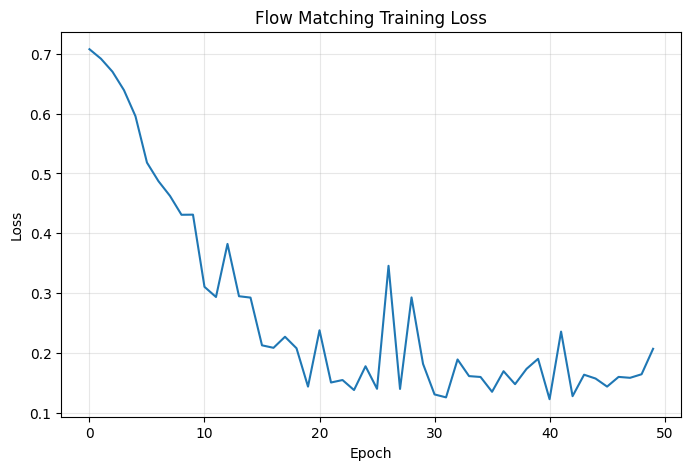

In [6]:
#train the model using FM
print("\nTraining Flow Matching Model...")
source_data = noise_points
target_data = points
losses = train_flow_matching(model, source_data, target_data, batch_size=64, num_epochs=50, lr=1e-3, device='cpu', warmup_epochs=5, use_wandb=False, project_name="ode-exp")
    
# Plot training loss
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Flow Matching Training Loss')
plt.grid(True, alpha=0.3)
plt.show()  


Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


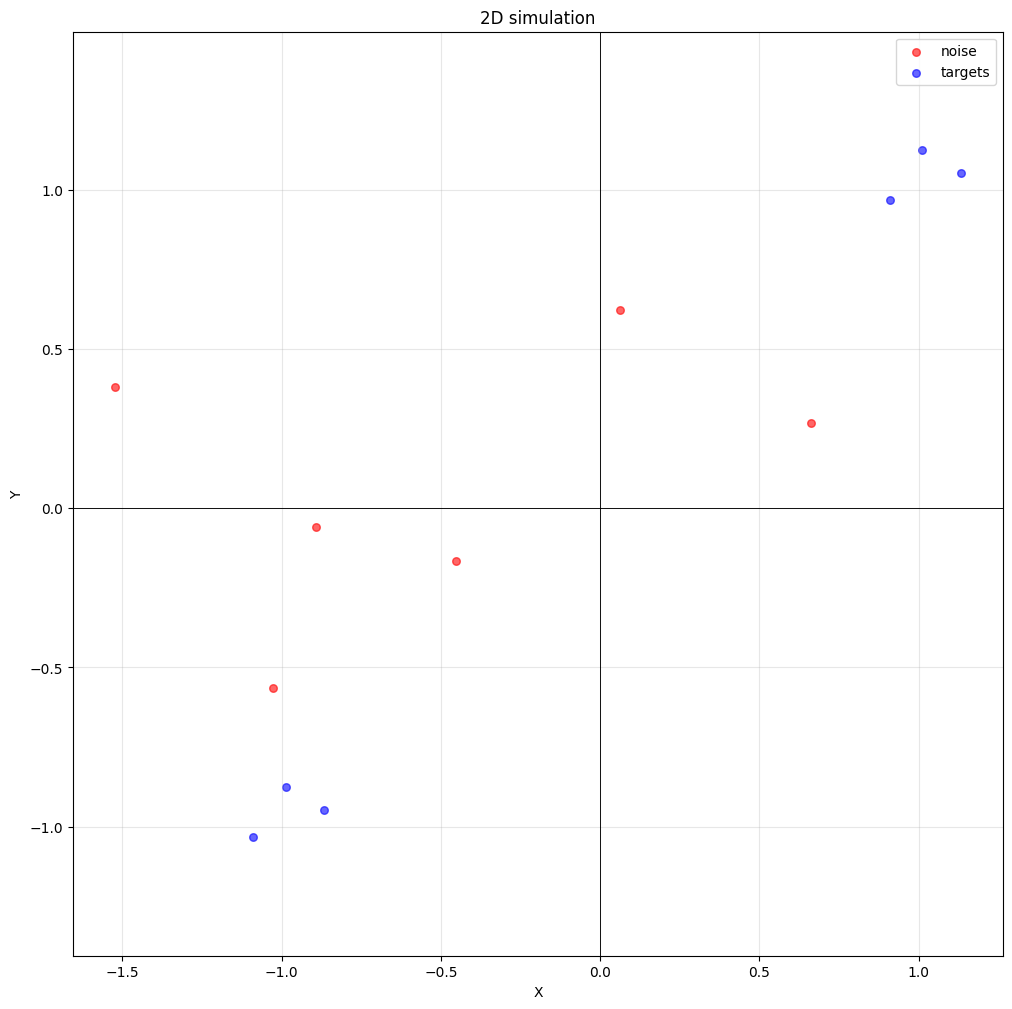

Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


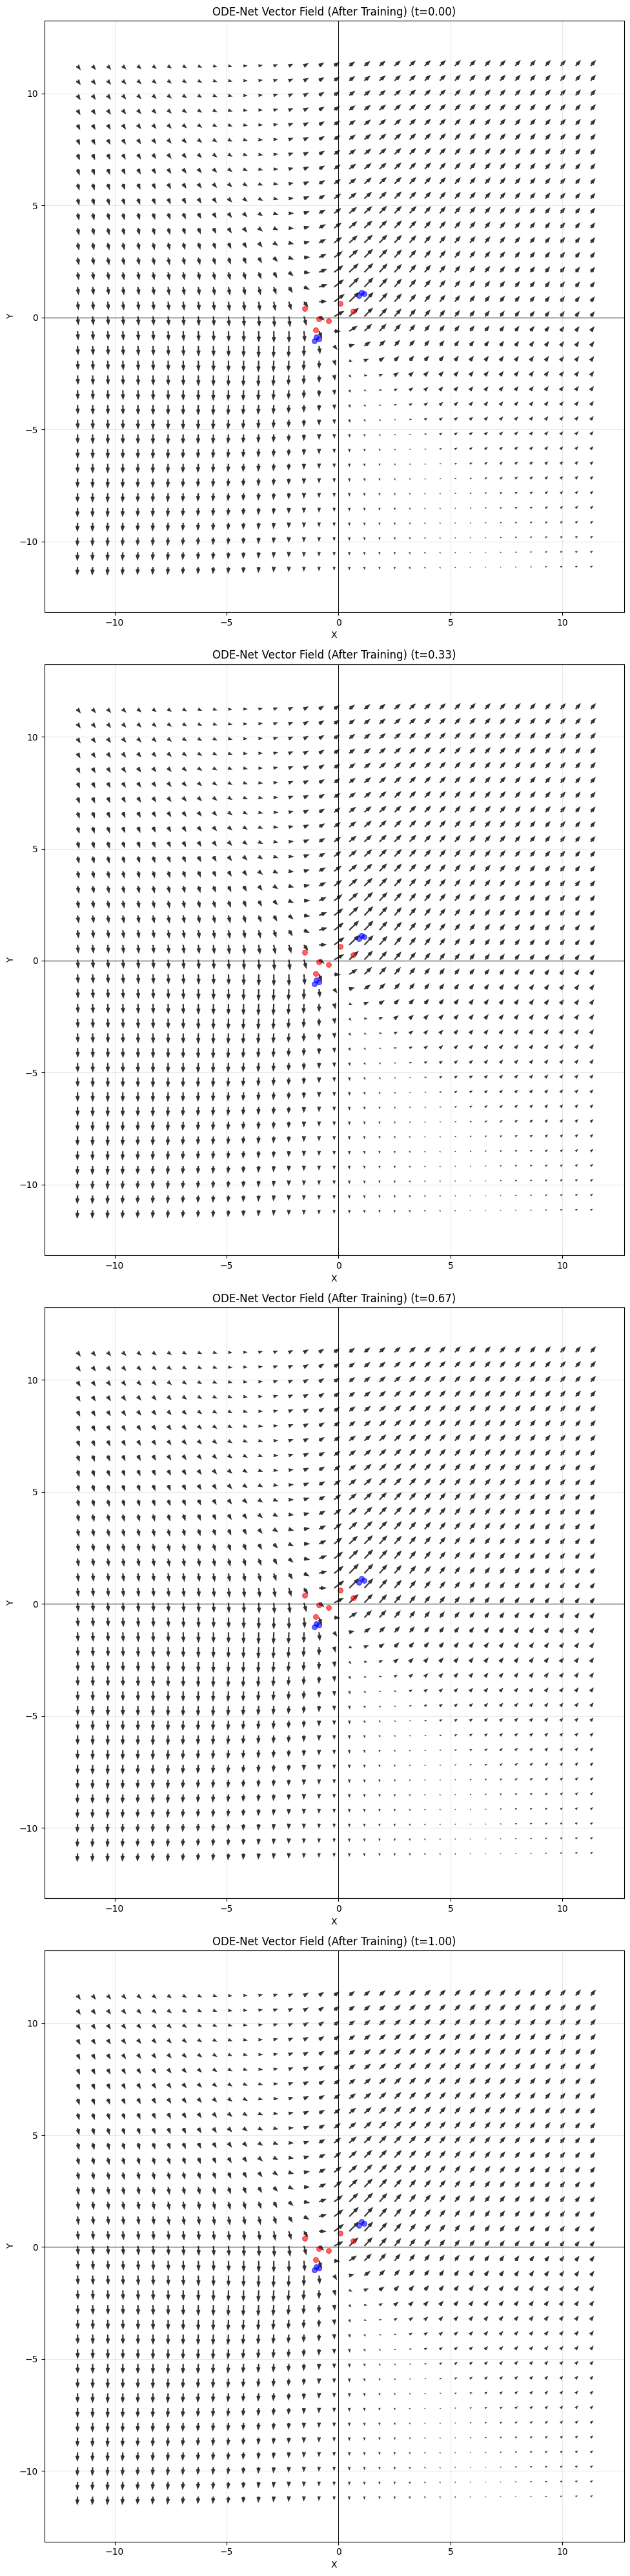

In [7]:
# Plot the vector field after training
ax = plot_points_2d(noise_points, title=None, color='red', figsize=(12, 12), show=False, label="noise")
ax = plot_points_2d(points, color='blue', title="2D simulation", ax=ax, show=False, label="targets")

# Get the current x-axis limits
left_xlim, right_xlim = ax.get_xlim()

# Get the current y-axis limits
bottom_ylim, top_ylim = ax.get_ylim()

##plot vector field
extend = 10
grid_size = 35
#ax = plot_vector_field(model, xlim=(left_xlim-extend, right_xlim+extend), ylim=(bottom_ylim-extend, top_ylim+extend), grid_size=grid_size, title='ODE-Net Vector Field (Before Training)', ax=ax, show=True)
ax = plot_vector_field_multi(model, noise_points, points, xlim=(left_xlim-extend, right_xlim+extend), ylim=(bottom_ylim-extend, top_ylim+extend),grid_size=grid_size, num_time_steps=4, title='ODE-Net Vector Field (After Training)', show=True)

In [8]:
def simulate_flow(model, initial_points, num_steps=10, device='cpu'):
    """
    Simulate the flow by following the vector field from t=0 to t=1.
    
    Args:
        model (nn.Module): Trained ODE-Net model
        initial_points (torch.Tensor): Starting points at t=0, shape (n_points, 2)
        num_steps (int): Number of time steps to simulate
        device (str): Device to run on
    
    Returns:
        torch.Tensor: Trajectory of points, shape (num_steps+1, n_points, 2)
    """
    model.eval()
    model = model.to(device)
    
    t_values = torch.linspace(0, 1, num_steps + 1, device=device)
    dt = 1.0 / num_steps
    
    trajectory = []
    x = initial_points.clone().to(device)
    trajectory.append(x.cpu())
    
    with torch.no_grad():
        for i in range(num_steps):
            t = torch.full((x.shape[0], 1), t_values[i].item(), device=device)
            
            # Get velocity from model
            v = model(x, t)
            
            # Euler integration: x_{t+dt} = x_t + v * dt
            x = x + v * dt
            
            trajectory.append(x.cpu())
    
    return torch.stack(trajectory, dim=0)


def plot_flow_evolution(model, initial_points, num_steps=10, num_time_plots=6, figsize=(15, 10), device='cpu', color='blue', title='Flow Evolution'):
    """
    Plot the distribution at different time steps as points flow through the vector field.
    
    Args:
        model (nn.Module): Trained ODE-Net model
        initial_points (torch.Tensor): Starting points at t=0
        num_steps (int): Number of integration steps for simulation
        num_time_plots (int): Number of time snapshots to plot
        figsize (tuple): Figure size
        device (str): Device to run on
        color (str): Color for points
        title (str): Title for the plot
    """
    # Simulate the flow
    trajectory = simulate_flow(model, initial_points, num_steps, device)
    
    # Select which time steps to plot
    plot_indices = torch.linspace(0, num_steps, num_time_plots).long()
    t_values = torch.linspace(0, 1, num_steps + 1)
    
    # Create subplots
    cols = min(3, num_time_plots)
    rows = (num_time_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if num_time_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    
    for idx, plot_idx in enumerate(plot_indices):
        points = trajectory[plot_idx]
        t_val = t_values[plot_idx].item()
        
        ax = axes[idx]
        ax.scatter(points[:, 0], points[:, 1], alpha=0.6, s=20, color=color)
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(f'{title} (t={t_val:.2f})')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='k', linewidth=0.5)
        ax.axvline(x=0, color='k', linewidth=0.5)
        ax.axis('equal')
        ax.set_xlim(-4, 4)
        ax.set_ylim(-4, 4)
    
    # Hide unused subplots
    for idx in range(num_time_plots, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

def plot_flow_density_evolution(model, initial_points, num_steps=10, num_time_plots=6, figsize=(15, 10), device='cpu', title='Density Evolution', xlim=(-4, 4), ylim=(-4, 4)):
    """
    Plot the density evolution using kernel density estimation as points flow through the vector field.
    
    Args:
        model (nn.Module): Trained ODE-Net model
        initial_points (torch.Tensor): Starting points at t=0
        num_steps (int): Number of integration steps for simulation
        num_time_plots (int): Number of time snapshots to plot
        figsize (tuple): Figure size
        device (str): Device to run on
        title (str): Title for the plot
        xlim (tuple): X-axis limits for density plot
        ylim (tuple): Y-axis limits for density plot
    """
    # Simulate the flow
    trajectory = simulate_flow(model, initial_points, num_steps, device)
    
    # Select which time steps to plot
    plot_indices = torch.linspace(0, num_steps, num_time_plots).long()
    t_values = torch.linspace(0, 1, num_steps + 1)
    
    # Create subplots
    cols = min(3, num_time_plots)
    rows = (num_time_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if num_time_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    
    # Create grid for density estimation
    xx, yy = np.mgrid[xlim[0]:xlim[1]:100j, ylim[0]:ylim[1]:100j]
    positions = np.vstack([xx.ravel(), yy.ravel()])
    
    for idx, plot_idx in enumerate(plot_indices):
        points = trajectory[plot_idx].numpy()
        t_val = t_values[plot_idx].item()
        
        ax = axes[idx]
        
        # Perform kernel density estimation
        if points.shape[0] > 1:
            kernel = gaussian_kde(points.T)
            density = kernel(positions).reshape(xx.shape)
            
            # Plot density as heatmap
            im = ax.contourf(xx, yy, density, levels=20, cmap='viridis')
            plt.colorbar(im, ax=ax)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(f'{title} (t={t_val:.2f})')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.5)
        ax.axvline(x=0, color='white', linewidth=0.5, alpha=0.5)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect('equal')
    
    # Hide unused subplots
    for idx in range(num_time_plots, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed y limits to fulfill fixed data aspect with adjustable data limits.


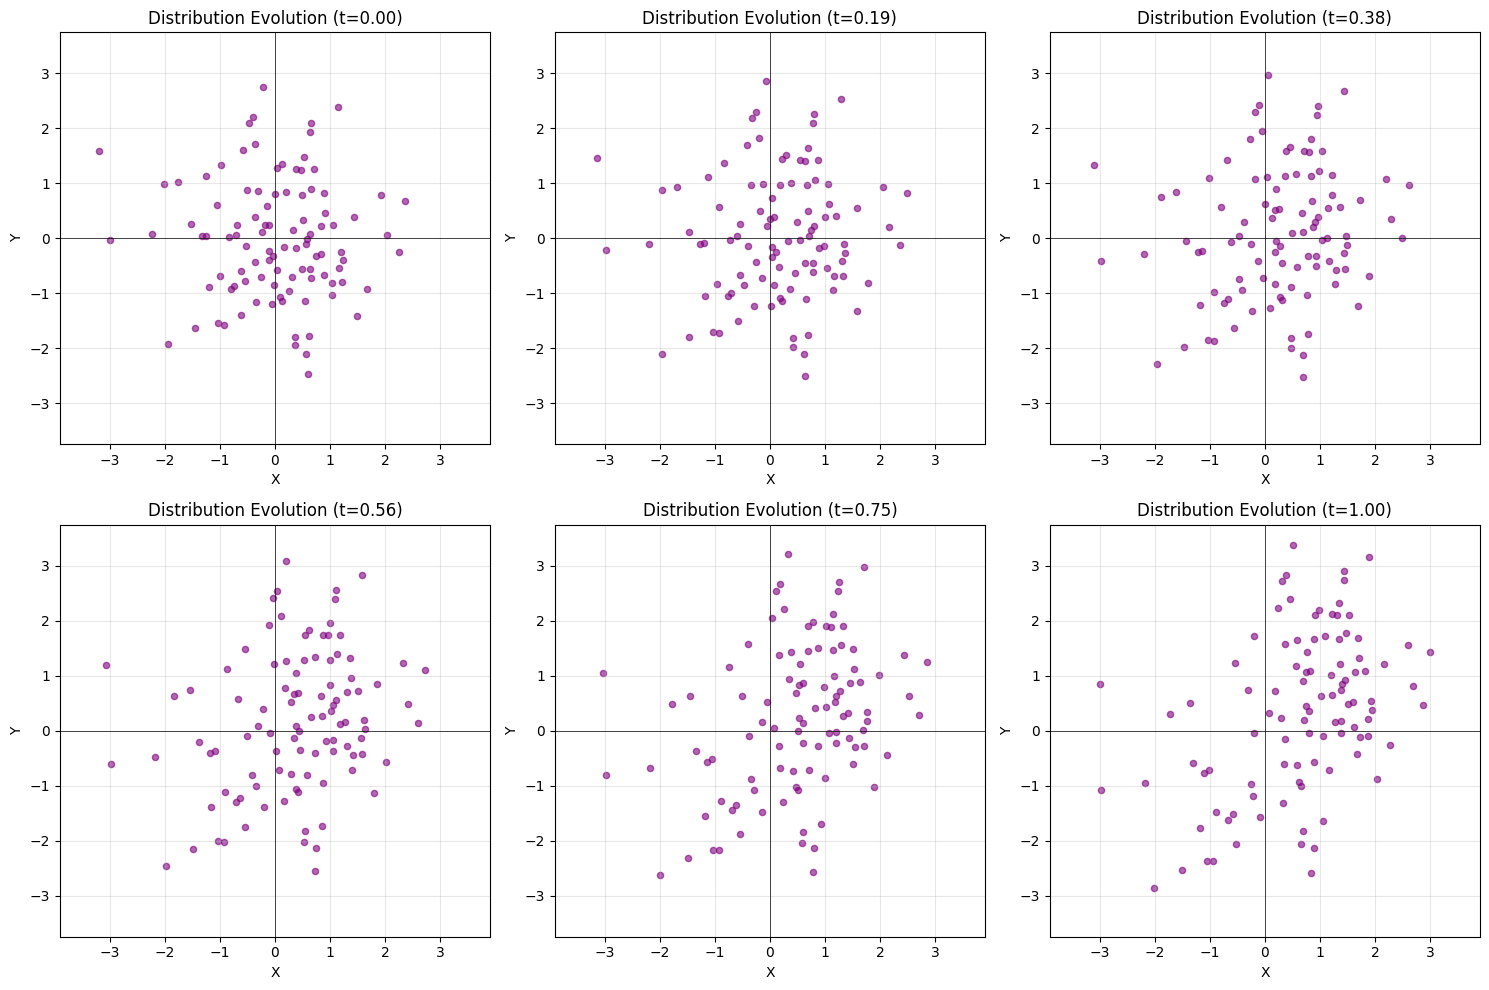

In [9]:
# Sample points at t=0 and visualize their flow evolution
test_points = generate_gaussian_point_2d(100, mean=0.0, std=1.0, seed=100)
plot_flow_evolution(model, test_points, num_steps=16, num_time_plots=6, color='purple', title='Distribution Evolution')

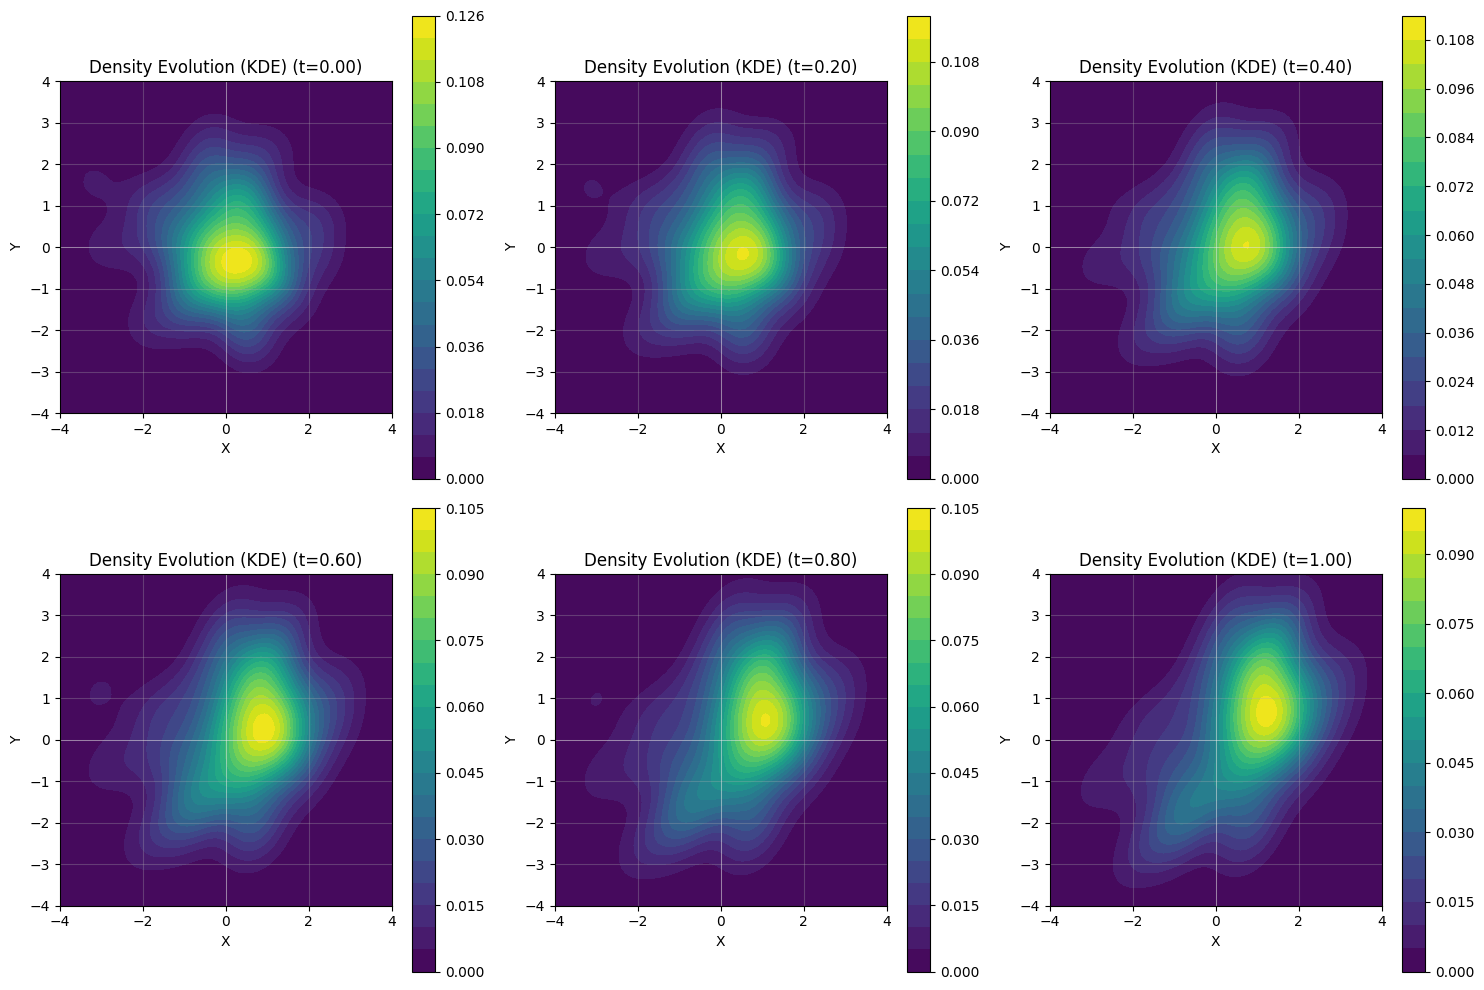

In [10]:
# Plot density evolution using KDE
plot_flow_density_evolution(model, test_points, num_steps=50, num_time_plots=6, title='Density Evolution (KDE)')

In [11]:
def compute_log_density_exact(model, x_t, t, source_log_prob, num_steps=100, device='cpu'):
    """
    Compute exact log density using instantaneous change of variables formula.
    
    Args:
        model (nn.Module): Trained ODE-Net model
        x_t (torch.Tensor): Points at time t, shape (n_points, 2)
        t (float): Current time value
        source_log_prob (callable): Function that computes log p(x) for source distribution
        num_steps (int): Number of integration steps from 0 to t
        device (str): Device to run on
    
    Returns:
        torch.Tensor: Log densities at x_t
    """
    model.eval()
    x_t = x_t.to(device)
    
    # Integrate backwards from t to 0 to find x_0
    dt = -t / num_steps
    t_values = torch.linspace(t, 0, num_steps + 1, device=device)
    
    x = x_t.clone()
    log_det_sum = torch.zeros(x.shape[0], device=device)
    
    #with torch.no_grad():
    for i in range(num_steps):
        t_curr = t_values[i]
        t_batch = torch.full((x.shape[0], 1), t_curr.item(), device=device)
        
        # Enable gradient computation for Jacobian
        x_temp = x.clone().requires_grad_(True)
        v = model(x_temp, t_batch)
        
        # Compute trace of Jacobian: tr(dv/dx)
        trace = torch.zeros(x.shape[0], device=device)
        for j in range(2):  # For 2D
            grad_outputs = torch.zeros_like(v)
            grad_outputs[:, j] = 1.0
            grad_v = torch.autograd.grad(v, x_temp, grad_outputs=grad_outputs, create_graph=False, retain_graph=True)[0]
            trace += grad_v[:, j]
        
        # Accumulate log determinant: d(log p)/dt = -tr(dv/dx)
        log_det_sum += trace * dt
        
        # Step backwards: x_{t-dt} = x_t - v * dt
        with torch.no_grad():
            x = x + v * dt
    
    # Compute log probability at x_0
    log_p_0 = source_log_prob(x)
    
    # Apply change of variables: log p(x_t) = log p(x_0) - integral(tr(dv/dx))
    log_p_t = log_p_0 + log_det_sum
    
    return log_p_t


def plot_flow_density_exact(model, num_steps=10, num_time_plots=6, figsize=(15, 10), device='cpu', title='Exact Density Evolution', xlim=(-4, 4), ylim=(-4, 4), grid_size=50):
    """
    Plot exact density evolution using instantaneous change of variables formula.
    
    Args:
        model (nn.Module): Trained ODE-Net model
        num_steps (int): Number of integration steps for density computation
        num_time_plots (int): Number of time snapshots to plot
        figsize (tuple): Figure size
        device (str): Device to run on
        title (str): Title for the plot
        xlim (tuple): X-axis limits
        ylim (tuple): Y-axis limits
        grid_size (int): Resolution of density grid
    """
    # Create grid
    x = torch.linspace(xlim[0], xlim[1], grid_size)
    y = torch.linspace(ylim[0], ylim[1], grid_size)
    xx, yy = torch.meshgrid(x, y, indexing='ij')
    grid_points = torch.stack([xx.flatten(), yy.flatten()], dim=1)
    
    # Source distribution: standard Gaussian
    def source_log_prob(x):
        return -0.5 * torch.sum(x**2, dim=1) - np.log(2 * np.pi)
    
    # Select time values to plot
    t_values = torch.linspace(0, 1, num_time_plots)
    
    # Create subplots
    cols = min(3, num_time_plots)
    rows = (num_time_plots + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if num_time_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if rows > 1 else [axes] if cols == 1 else axes
    
    for idx, t_val in enumerate(t_values):
        if t_val == 0:
            # At t=0, use source distribution
            log_densities = source_log_prob(grid_points)
        else:
            # Compute exact density at time t
            log_densities = compute_log_density_exact(model, grid_points, t_val.item(), source_log_prob, num_steps, device)
        
        densities = torch.exp(log_densities).reshape(grid_size, grid_size).cpu().numpy()
        
        ax = axes[idx]
        im = ax.contourf(xx.numpy(), yy.numpy(), densities, levels=20, cmap='viridis')
        plt.colorbar(im, ax=ax)
        
        ax.set_xlabel('X')
        ax.set_ylabel('Y')
        ax.set_title(f'{title} (t={t_val:.2f})')
        ax.grid(True, alpha=0.3)
        ax.axhline(y=0, color='white', linewidth=0.5, alpha=0.5)
        ax.axvline(x=0, color='white', linewidth=0.5, alpha=0.5)
        ax.set_xlim(xlim)
        ax.set_ylim(ylim)
        ax.set_aspect('equal')
    
    # Hide unused subplots
    for idx in range(num_time_plots, len(axes)):
        axes[idx].axis('off')
    
    plt.tight_layout()
    plt.show()

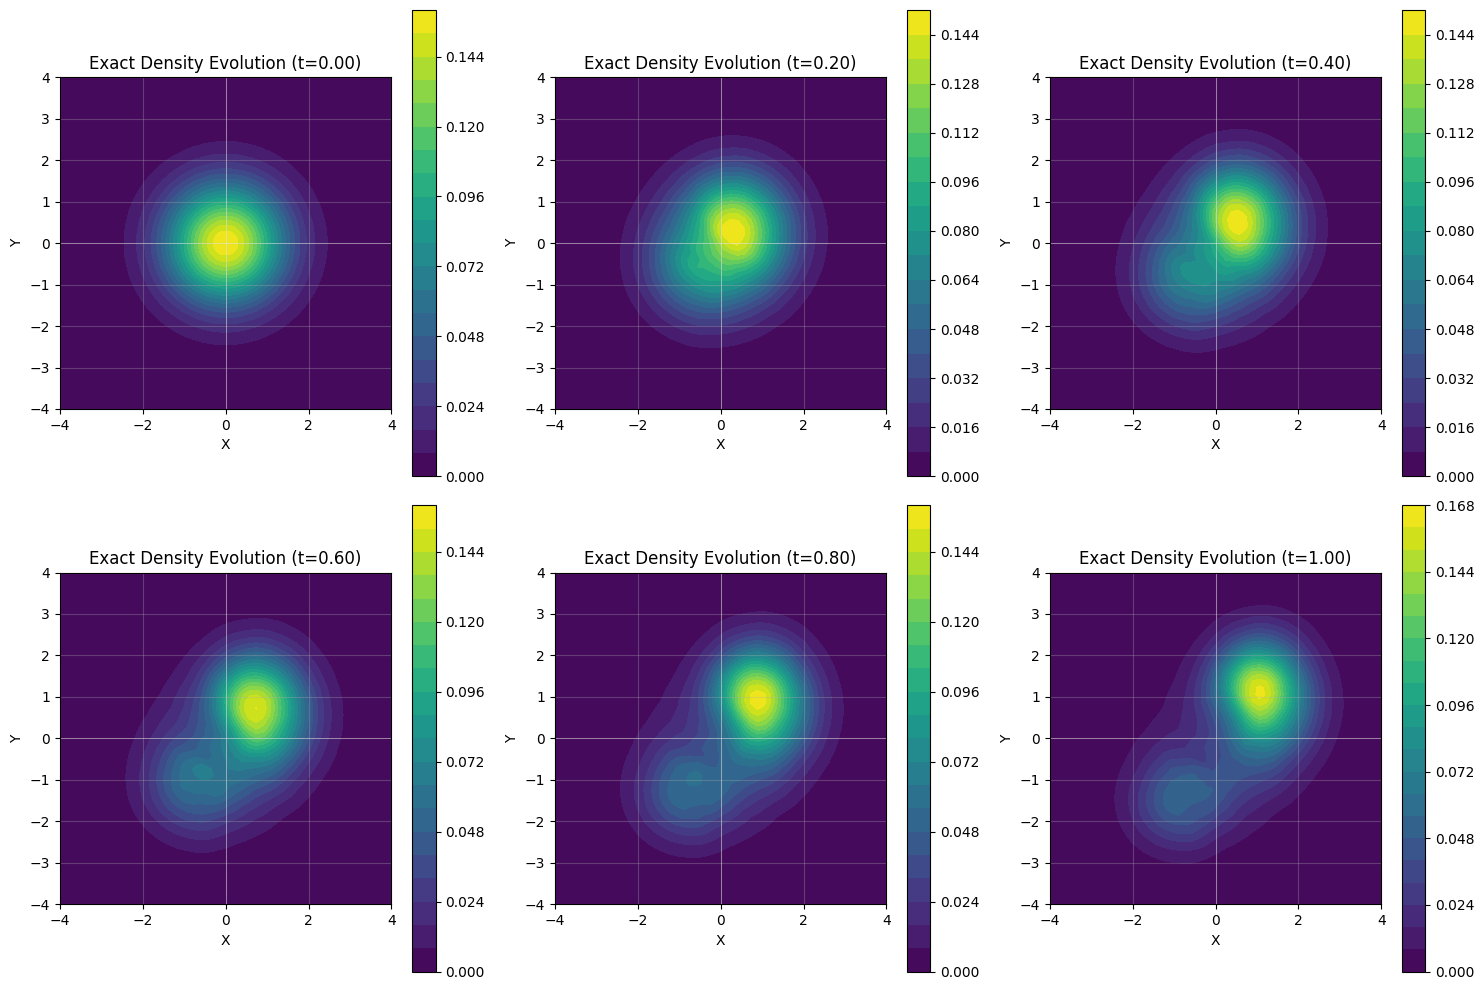

In [12]:
# Plot exact density evolution using change of variables
plot_flow_density_exact(model, num_steps=50, num_time_plots=6, title='Exact Density Evolution', grid_size=50)